# Bloc 3C — Classification du risque de retard

Analyse exploratoire de `features_detail` (grain tache) pour la cible
`est_en_retard`, et diagnostic d'apprentissage du Decision Tree retenu dans
`models/model_classification_retard.pkl`. Table volumineuse (~940 000
lignes) : le chargement prend une bonne minute, la suite est rapide.

In [1]:
from _setup import engine, save, PROJECT_ROOT, COULEUR_PRINCIPALE, COULEUR_ALERTE, COULEUR_NEUTRE, PALETTE_CATEGORIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLOC = "retard"

df = pd.read_sql("SELECT * FROM features_detail", engine, parse_dates=["Date_Creation"])
print(f"{len(df)} lignes chargees")

seuil_retard_j = df["duree_traitement_reelle_j"].quantile(0.75)
df["est_en_retard"] = (df["duree_traitement_reelle_j"] > seuil_retard_j).astype(int)
df_clf = df[df["duree_traitement_reelle_j"].notna()].copy()
print(f"lignes avec duree connue : {len(df_clf)} / {len(df)} ({len(df_clf)/len(df)*100:.1f}%)")
print(f"seuil de retard (P75) : {seuil_retard_j:.1f} jours")
print(f"taux de retard global : {df_clf['est_en_retard'].mean()*100:.1f}%")

939015 lignes chargees


lignes avec duree connue : 717566 / 939015 (76.4%)
seuil de retard (P75) : 3.0 jours
taux de retard global : 15.3%


**Lecture.** 76.4% des taches ont une duree de traitement connue (717 566 /
939 015) -- les autres sont des dossiers encore ouverts au moment de
l'extraction (pas de `Date_Cloture`), pas des donnees manquantes au sens
d'un defaut de collecte. Le seuil de retard (75e percentile de la duree,
soit 3.0 jours) donne un taux de retard global de 15.3% : la classe positive
est minoritaire, ce qui justifie `class_weight="balanced"` dans le modele et
l'ajustement du seuil de decision fait plus loin dans le pipeline plutot
qu'un seuil brut a 0.5.

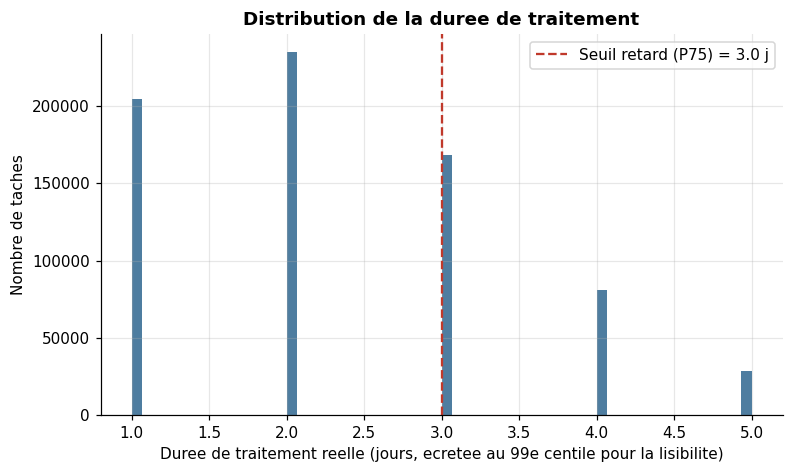

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
duree = df["duree_traitement_reelle_j"].dropna()
ax.hist(duree.clip(upper=duree.quantile(0.99)), bins=60, color=COULEUR_PRINCIPALE, alpha=0.85)
ax.axvline(seuil_retard_j, color=COULEUR_ALERTE, linestyle="--", label=f"Seuil retard (P75) = {seuil_retard_j:.1f} j")
ax.set_xlabel("Duree de traitement reelle (jours, ecretee au 99e centile pour la lisibilite)")
ax.set_ylabel("Nombre de taches")
ax.set_title("Distribution de la duree de traitement")
ax.legend()
save(fig, BLOC, "01_distribution_duree.png")
plt.show()

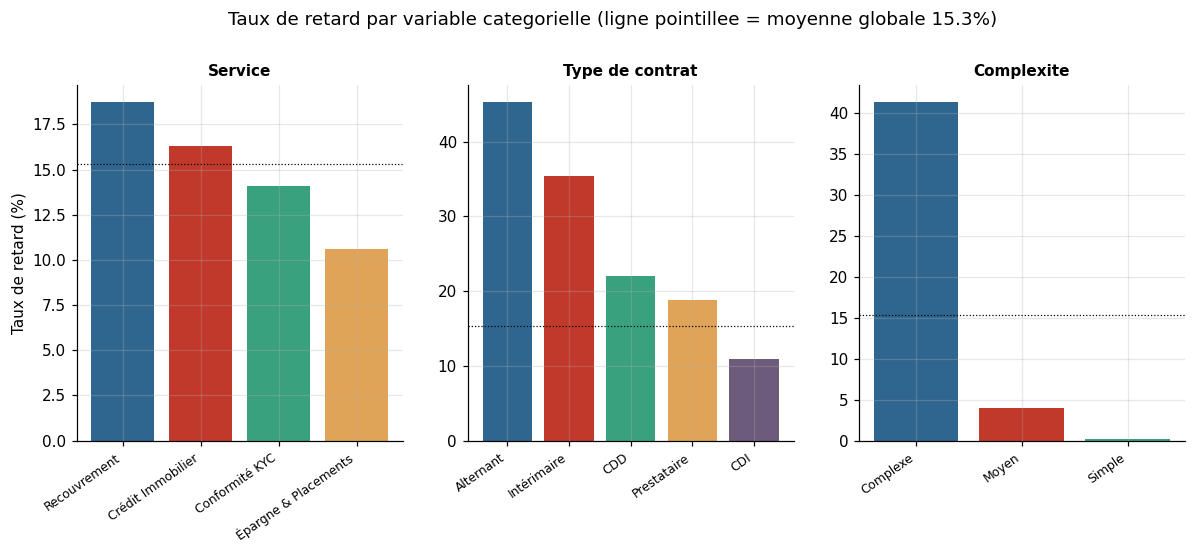

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
groupes = [("Service", axes[0], "Service"), ("Type_Contrat", axes[1], "Type de contrat"), ("Complexite", axes[2], "Complexite")]
for col, ax, titre in groupes:
    taux = (df_clf.groupby(col)["est_en_retard"].mean() * 100).sort_values(ascending=False)
    ax.bar(range(len(taux)), taux.values, color=PALETTE_CATEGORIES[:len(taux)])
    ax.set_xticks(range(len(taux)))
    ax.set_xticklabels(taux.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(titre, fontsize=10)
    ax.axhline(df_clf["est_en_retard"].mean() * 100, color="black", linewidth=0.8, linestyle=":")
axes[0].set_ylabel("Taux de retard (%)")
fig.suptitle("Taux de retard par variable categorielle (ligne pointillee = moyenne globale 15.3%)", y=1.04)
save(fig, BLOC, "02_taux_retard_categoriel.png")
plt.show()

**Lecture.** Le Service pese peu (10.6% a Epargne & Placements, 18.8% a
Recouvrement -- un facteur 1.8 entre les deux extremes) comparee au Type de
contrat, ou l'ecart explose : 45.3% de retard chez les alternants contre
11.0% chez les CDI, un facteur 4. La Complexite est le facteur le plus
tranche des trois : 0.2% de retard sur les dossiers simples, 4.0% sur les
moyens, 41.4% sur les complexes -- une progression qui n'est pas lineaire
mais quasi exponentielle avec le niveau de complexite. Ces trois lectures se
recoupent avec l'anciennete moyenne plus faible des alternants et
interimaires (deja visible dans la correlation negative anciennete/retard
calculee plus loin) : le risque de retard tient moins au service qu'a
l'experience de l'agent et a la difficulte intrinseque du dossier.

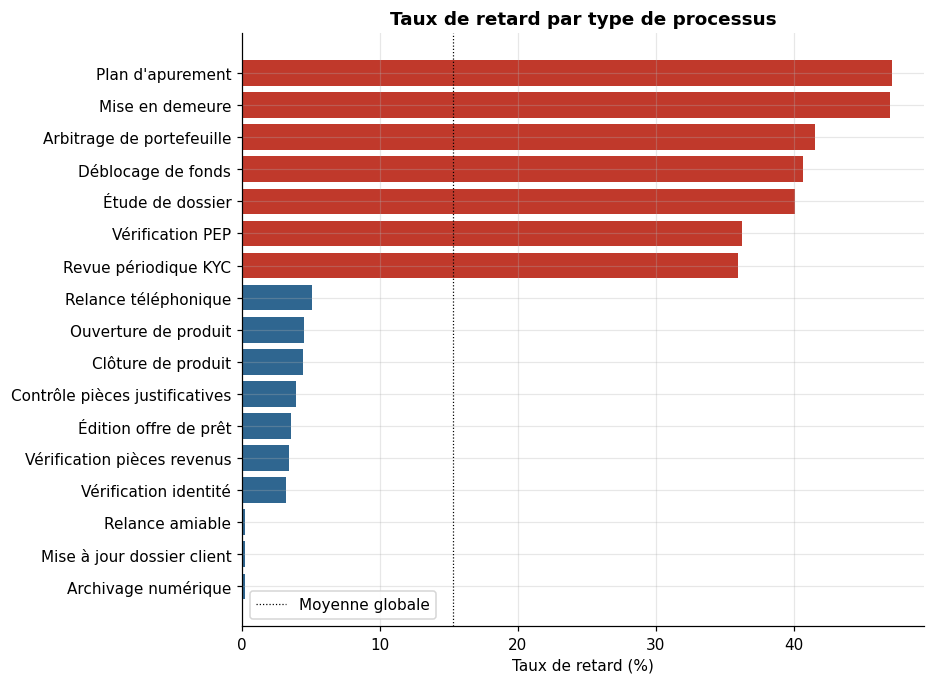

In [4]:
taux_process = (df_clf.groupby("Type_Processus")["est_en_retard"].mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
couleurs = [COULEUR_ALERTE if v > df_clf["est_en_retard"].mean() * 100 else COULEUR_PRINCIPALE for v in taux_process.values]
ax.barh(taux_process.index, taux_process.values, color=couleurs)
ax.axvline(df_clf["est_en_retard"].mean() * 100, color="black", linewidth=0.8, linestyle=":", label="Moyenne globale")
ax.set_xlabel("Taux de retard (%)")
ax.set_title("Taux de retard par type de processus")
ax.legend()
save(fig, BLOC, "03_taux_retard_processus.png")
plt.show()

**Lecture.** L'ecart va de 5.1% (relances telephoniques, un processus court
et standardise) a 47.1% (plans d'apurement) et 47.0% (mises en demeure) --
deux processus de recouvrement qui impliquent typiquement des allers-retours
avec le client ou un tiers, donc des delais moins maitrisables par l'agent
seul. C'est un ecart de facteur 9 entre le processus le plus rapide et le
plus a risque, plus large que tous les autres facteurs categoriels observes
jusqu'ici -- ce qui confirme, du cote des donnees, pourquoi l'encodage de
`Type_Processus` (absent du notebook d'origine) a fait gagner 5.7 points
d'accuracy et 3.5 points de F1 lors du portage (cf.
`AMELIORATION_MODELES.md`, Bloc 3C).

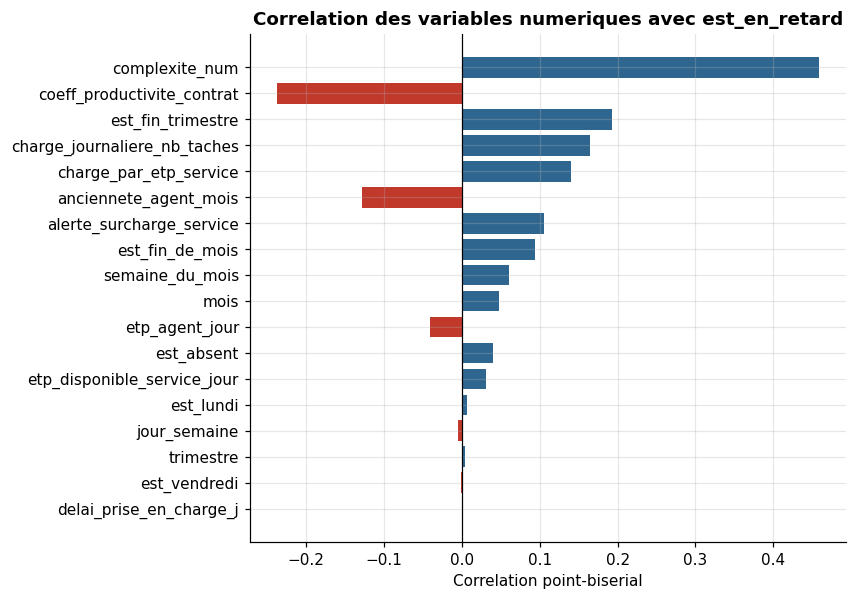

In [5]:
FEATURES_NUM = [
    "complexite_num", "coeff_productivite_contrat",
    "charge_journaliere_nb_taches", "etp_agent_jour",
    "etp_disponible_service_jour", "charge_par_etp_service",
    "anciennete_agent_mois", "delai_prise_en_charge_j",
    "jour_semaine", "mois", "trimestre", "semaine_du_mois",
    "est_fin_de_mois", "est_fin_trimestre", "est_lundi", "est_vendredi",
    "est_absent", "alerte_surcharge_service",
]
for c in FEATURES_NUM:
    df_clf[c] = pd.to_numeric(df_clf[c], errors="coerce")
corrs = df_clf[FEATURES_NUM + ["est_en_retard"]].corr()["est_en_retard"].drop("est_en_retard")
corrs = corrs.sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
couleurs = [COULEUR_ALERTE if v < 0 else COULEUR_PRINCIPALE for v in corrs.values]
ax.barh(corrs.index[::-1], corrs.values[::-1], color=couleurs[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation des variables numeriques avec est_en_retard")
ax.set_xlabel("Correlation point-biserial")
save(fig, BLOC, "04_correlations_numeriques.png")
plt.show()

**Lecture.** `complexite_num` domine largement (0.459), coherent avec l'ecart
deja observe sur `Complexite`. `coeff_productivite_contrat` suit en negatif
(-0.238) : les contrats moins productifs en moyenne sont aussi ceux qui
prennent le plus de retard, meme lecture que le facteur 4 observe sur
`Type_Contrat`. `est_fin_trimestre` (0.192) confirme un troisieme fois --
apres les blocs 3A et 3B -- que les cloture trimestrielles degradent un
indicateur operationnel, ici le respect des delais. Plus surprenant :
`delai_prise_en_charge_j` (le temps avant qu'un agent commence a traiter le
dossier) n'affiche quasiment aucune correlation lineaire avec le retard final
(0.001), alors qu'intuitivement un dossier pris en charge tardivement
semblerait parti pour finir en retard. Deux explications possibles, non
tranchees ici : soit la relation existe mais n'est pas lineaire (un modele
a base d'arbre peut la capter via un seuil, la ou Pearson ne voit rien), soit
le temps de prise en charge est deja largement absorbe par les agents avant
que la duree totale ne s'en ressente.

## Courbe d'apprentissage (Decision Tree retenu)

`est_en_retard` est une classification tache par tache, pas une serie a
prevoir par recurrence : la encore, une fenetre expansive chronologique
suffit. On reprend les hyperparametres retenus dans
`model_classification_retard.pkl` (`max_depth=4`, `min_samples_leaf=20`,
`class_weight="balanced"`), seuil de decision par defaut (0.5) -- l'ajustement
du seuil optimal (0.758 en production) est une etape separee, posterieure au
choix du modele, qui n'a pas de raison de varier avec la taille du train de
la meme facon.

train=502296  val=107634  test=107636


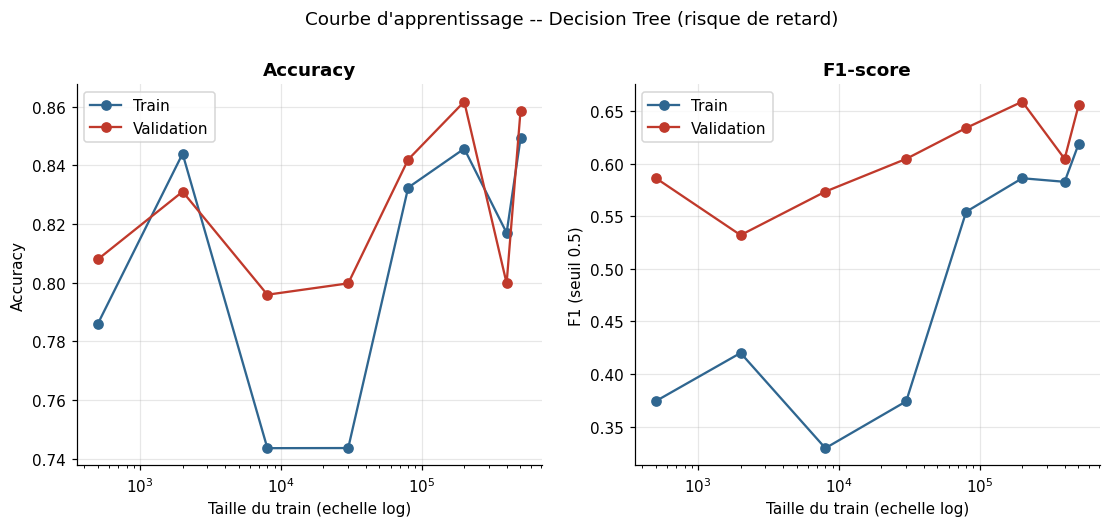

taille=    500  acc_train=0.786  acc_val=0.808  f1_train=0.374  f1_val=0.586
taille=   2000  acc_train=0.844  acc_val=0.831  f1_train=0.420  f1_val=0.532
taille=   8000  acc_train=0.744  acc_val=0.796  f1_train=0.330  f1_val=0.574
taille=  30000  acc_train=0.744  acc_val=0.800  f1_train=0.374  f1_val=0.605
taille=  80000  acc_train=0.832  acc_val=0.842  f1_train=0.554  f1_val=0.634
taille= 200000  acc_train=0.846  acc_val=0.862  f1_train=0.586  f1_val=0.659
taille= 400000  acc_train=0.817  acc_val=0.800  f1_train=0.583  f1_val=0.605
taille= 502296  acc_train=0.849  acc_val=0.859  f1_train=0.619  f1_val=0.655


In [6]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "notebooks_avec_ecriture_dans_database"))
from modelisation_common import split_temporel
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

df_dummies = pd.get_dummies(df_clf, columns=["Service", "Type_Contrat", "Type_Processus"], prefix=["svc", "ctr", "proc"])
features_dummies = [c for c in df_dummies.columns if c.startswith(("svc_", "ctr_", "proc_"))]
FEATURES = [f for f in FEATURES_NUM + features_dummies if f in df_dummies.columns]
TARGET = "est_en_retard"

df_model = df_dummies[FEATURES + [TARGET, "Date_Creation"]].dropna().copy()
df_model = df_model.sort_values("Date_Creation").reset_index(drop=True)
df_train, df_val, df_test = split_temporel(df_model)
print(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

tailles = [500, 2000, 8000, 30000, 80000, 200000, 400000, len(df_train)]
acc_train, acc_val, f1_train, f1_val = [], [], [], []
for taille in tailles:
    sous_train = df_train.iloc[:taille]
    m = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, class_weight="balanced", random_state=42)
    m.fit(sous_train[FEATURES], sous_train[TARGET])
    pred_train, pred_val = m.predict(sous_train[FEATURES]), m.predict(df_val[FEATURES])
    acc_train.append(accuracy_score(sous_train[TARGET], pred_train))
    acc_val.append(accuracy_score(df_val[TARGET], pred_val))
    f1_train.append(f1_score(sous_train[TARGET], pred_train))
    f1_val.append(f1_score(df_val[TARGET], pred_val))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(tailles, acc_train, marker="o", color=COULEUR_PRINCIPALE, label="Train")
axes[0].plot(tailles, acc_val, marker="o", color=COULEUR_ALERTE, label="Validation")
axes[0].set_xscale("log")
axes[0].set_xlabel("Taille du train (echelle log)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(tailles, f1_train, marker="o", color=COULEUR_PRINCIPALE, label="Train")
axes[1].plot(tailles, f1_val, marker="o", color=COULEUR_ALERTE, label="Validation")
axes[1].set_xscale("log")
axes[1].set_xlabel("Taille du train (echelle log)")
axes[1].set_ylabel("F1 (seuil 0.5)")
axes[1].set_title("F1-score")
axes[1].legend()
fig.suptitle("Courbe d'apprentissage -- Decision Tree (risque de retard)", y=1.03)
save(fig, BLOC, "05_courbe_apprentissage.png")
plt.show()

for t, a1, a2, f1_, f2_ in zip(tailles, acc_train, acc_val, f1_train, f1_val):
    print(f"taille={t:7d}  acc_train={a1:.3f}  acc_val={a2:.3f}  f1_train={f1_:.3f}  f1_val={f2_:.3f}")

**Lecture.** Le schema est different de celui des blocs 3A et 3B : ici, pas
de surapprentissage classique. Le fosse train/validation, quand il existe,
est faible et parfois meme inverse (l'accuracy de validation depasse
l'accuracy de train a plusieurs tailles, par exemple 0.842 contre 0.832 a
80 000 lignes) -- coherent avec un arbre volontairement peu profond
(`max_depth=4`) et pondere pour la classe minoritaire : un modele a fort
biais et faible variance n'a tout simplement pas la capacite de memoriser le
train, meme petit. La vraie instabilite est ailleurs : entre 500 et 30 000
lignes, l'accuracy oscille (0.786 puis 0.844 puis 0.744 puis 0.744) selon la
proportion de dossiers complexes et de types de processus a risque que le
sous-echantillon chronologique contient par hasard. A 400 000 lignes,
accuracy et F1 baissent nettement (0.800 et 0.605 en validation, contre 0.862
et 0.659 a 200 000) avant de remonter au train complet -- signe qu'une
tranche de la periode couverte a cette taille est plus difficile a
classifier avec seulement 4 niveaux de profondeur, sans que ca degrade le
resultat final une fois tout l'historique disponible. Au train complet
(502 296 lignes), le modele retrouve une accuracy de 0.849 sur le train et
0.859 sur la validation, avec un F1 de 0.655 en validation -- des valeurs
tres proches de celles rapportees en production (accuracy test = 0.849,
F1 test = 0.666 apres ajustement du seuil, cf. `AMELIORATION_MODELES.md`).
La conclusion pour ce bloc n'est donc pas "il manque des donnees" mais
plutot "le modele a deja converge bien avant la taille maximale du train" --
la limite ici est la profondeur volontairement restreinte de l'arbre, pas
le volume disponible.

## Synthese du bloc

Le risque de retard est domine par la complexite du dossier et le type de
contrat de l'agent, loin devant le service ou le jour de la semaine ; le
type de processus ajoute un facteur additionnel important (x9 entre le plus
rapide et le plus a risque), ce qui confirme l'apport documente de son
encodage. La classe positive est minoritaire (15.3%), d'ou l'usage de
`class_weight="balanced"` et d'un seuil de decision ajuste plutot que le
seuil par defaut. La courbe d'apprentissage ne montre pas de surapprentissage
classique -- l'arbre est trop peu profond pour memoriser meme un petit train
-- mais une sensibilite a la composition du sous-echantillon sur les tailles
intermediaires, qui s'attenue une fois l'historique complet utilise.